In [1]:
import sys, os
import importlib
from importlib import reload
# importlib.import_module(module_name)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy
import tqdm
import joblib

sys.path.append("../../../python")
from simhelper import util, root, generator, parser
from simhelper import datatypes
from simhelper import helper_basic as hp
reload(parser)
reload(datatypes)

sys.path.append("..")
import cut_functions
reload(cut_functions)


# # importing required libraries 
# import ipympl
# # %matplotlib inline 
# %matplotlib widget 

np.set_printoptions(edgeitems=30, linewidth=100000, 
    precision=3)

Welcome to JupyROOT 6.28/10


In [3]:
# data_dir="/home/tomren/geant_projects/musim_test"
data_dir="/project/6075887/MATHUSLA/simulation/"

In [103]:
reload = False
efficiency = 0.95

fname_bkg        = f"{data_dir}//genie/genie_output_2025_10/g4_output/recon_skim_merged.root"
fname_bkg_joblib = f"{data_dir}//genie/genie_output_2025_10/g4_output/rrq_bkg_nv_eff{efficiency:.2f}.joblib"

# fname_bkg = f"{data_dir}//genie/genie_output_2025_10/g4_output/run_2/run_0_digi_recon_skim.root"
# fname_bkg_joblib = f"{data_dir}//genie/genie_output_2025_10/g4_output/run_2/rrq_bkg_eff{efficiency:.2f}.joblib"
 

fname_sig1 = f"{data_dir}/llp/rrq_sig1_cosmic_eff0.95.joblib"
fname_sig2 = f"{data_dir}/llp/rrq_sig2_cosmic_eff0.95.joblib"


fbkg = root.tfile_reader(fname_bkg)
fbkg.ls()
## Get metadata
fbkg.get_tree("metadata_digi")
metadata_digi = fbkg.get_entry(0)
fbkg.get_tree("data;1")
print("Entries", fbkg.entries)

if reload:
    res_bkg = cut_functions.run_processing(fbkg, entries=-1, efficiency = efficiency);
    joblib.dump(res_bkg.data, fname_bkg_joblib)
else:
    res_bkg_data = joblib.load(fname_bkg_joblib)
    res_bkg = cut_functions.RQ_dict(res_bkg_data)


res_sig1_data = joblib.load(fname_sig1)
res_sig2_data = joblib.load(fname_sig2)     
res_sig1 = cut_functions.RQ_dict(res_sig1_data)
res_sig2 = cut_functions.RQ_dict(res_sig2_data)

None
Entries 92363
Entries 92363
Finished
TFile**		/project/6075887/MATHUSLA/simulation///genie/genie_output_2025_10/g4_output/recon_skim_merged.root	
 TFile*		/project/6075887/MATHUSLA/simulation///genie/genie_output_2025_10/g4_output/recon_skim_merged.root	
  KEY: TTree	metadata;1	Metadata for reconstruction
  KEY: TTree	metadata_digi;1	Metadata for digitization
  KEY: TTree	metadata_recon;1	Simulation metadata
  KEY: TParameter<int>	N_MERGED;1	
  KEY: TTree	data;1	Reconstruction Tree Skimmed


In [104]:
colors = ["C0", "C2", "C1"]
labels = ["bb 25 GeV", "bb 45 GeV", "Bkg n"]

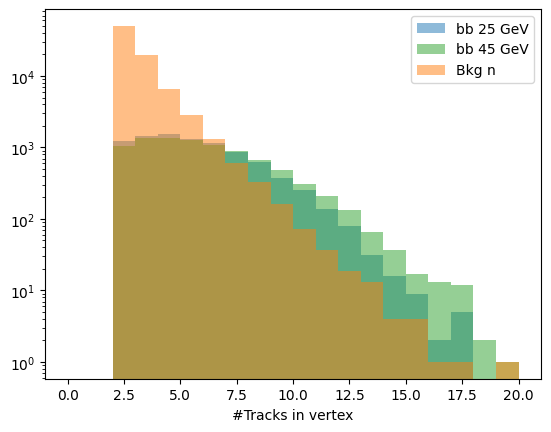

In [105]:
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
# for i, res in enumerate([res_bkg]):
    # plt.hist(res["vertex_ntracks"] - res["vertex_ndownward_track"], bins=20,range=(0,20), alpha=0.5);
    plt.hist(res["vertex_ntracks"], bins=20,range=(0,20), alpha=0.5, color=colors[i], label=labels[i])
plt.yscale("log")
plt.xlabel("#Tracks in vertex")
plt.legend()
plt.show()

Text(0.5, 0, 'Hits to vertex speed [mm/ns]')

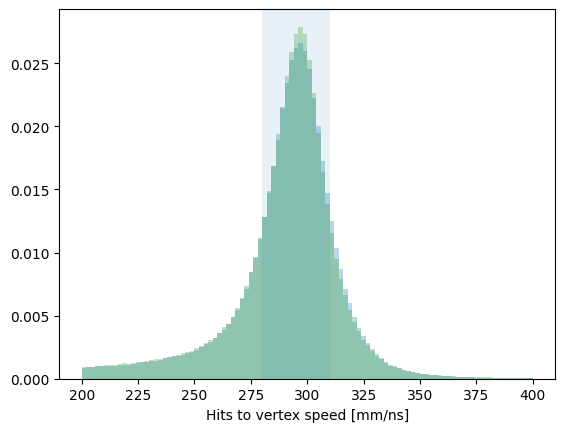

In [106]:
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    mask = res.get_cut("More than 2 tracks") #| res.get_cut("True")
    y = util.Utils.flatten1d(res["vertex_comp_metric_speed"][:][mask])
    plt.hist(y, bins=100, range=[200,400], alpha=0.3, color=colors[i], density=1)
plt.axvspan(295-15, 295+15, alpha=0.1)
plt.xlabel("Hits to vertex speed [mm/ns]")

In [107]:
# res = res_bkg
# p = np.linalg.norm(res["gen_p3"], axis=1)
# m =939
# ek = np.sqrt(p**2 + m**2)  - m
# n,ibins = np.histogram(ek, bins=np.logspace(1,7,200));
# plt.stairs(n/np.diff(ibins), ibins)
# plt.yscale("log")
# plt.xscale("log")
# plt.xlabel("Ekin [MeV]")
# plt.ylabel("Counts/MeV")

In [108]:
# print(sum(ek>2670))

0.8418902506348681


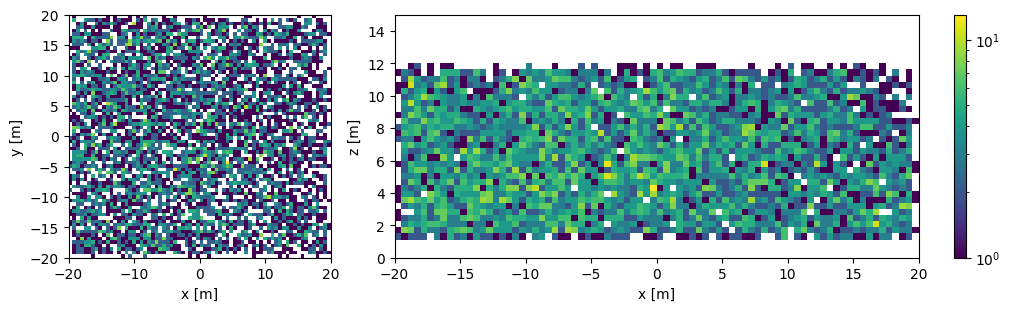

0.857429718875502


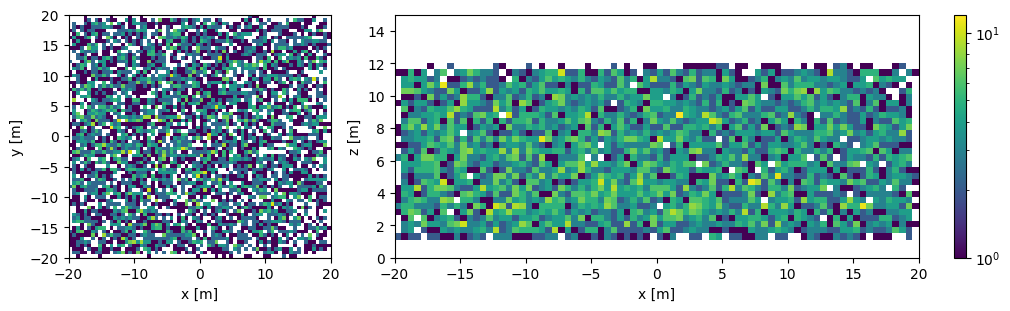

0.2390478168953845


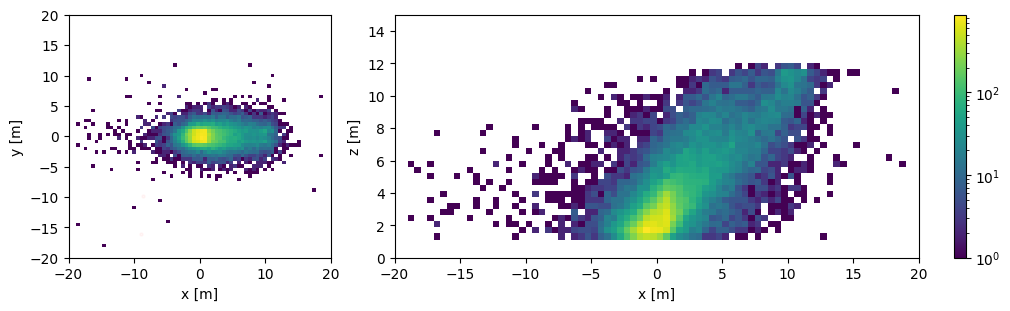

In [114]:
def c_fid(res):
    pillar_locations = [[i*10700,j*10700] for i in range(-2,2) for j in range(-2,3)]
    pillar_locations_right = [[i*10700,j*10700] for i in [2] for j in range(-2,3)]
    cut_range = 1000
    cut_range_right = 1200
    mask = np.ones_like(res["vertex_ndigi"], dtype=bool)
    for x,y in pillar_locations:
        mask = mask & ((abs(res["vertex_xyzt"][:,0]-x)>cut_range) | (abs(res["vertex_xyzt"][:,1]-y)>cut_range))

    for x,y in pillar_locations_right:
        mask = mask & ((abs(res["vertex_xyzt"][:,0]-x)>cut_range_right) | (abs(res["vertex_xyzt"][:,1]-y)>cut_range_right))    
    return mask
    

for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    res.add_cut(c_fid, "Fiducial volume")
    
    mask = res.get_cut("More than 2 tracks")# & res.get_cut("N track downward")#| res.get_cut("True")
    mask_fid = res.get_cut("More than 2 tracks") & res.get_cut("Fiducial volume")#| res.get_cut("True")
    # print(sum(mask))
    print(sum(mask_fid)/len(mask_fid))
    
    
    fig = plt.figure(figsize=(10,3), layout="constrained")
    spec = fig.add_gridspec(1,3)
    
    ax1 = fig.add_subplot(spec[:, :1])
    ax2 = fig.add_subplot(spec[:, 1:])


    x = (res["vertex_xyzt"][:,0])[mask]/1000
    y = (res["vertex_xyzt"][:,1])[mask]/1000
    x_reject = (res["vertex_xyzt"][:,0])[mask&~mask_fid]
    y_reject = (res["vertex_xyzt"][:,1])[mask&~mask_fid]    
    ax1.hist2d(x, y, bins=(70,70), norm=mpl.colors.LogNorm(), range=((-20,20),(-20,20)))
    # ax1.scatter(x, y, alpha=0.83 - np.heaviside(i-1,0)*0.8, s=20 - np.heaviside(i-1,0)*19, color=colors[i])
    ax1.scatter(x_reject, y_reject, alpha=0.83 - np.heaviside(i-1,0)*0.8, s=10 - np.heaviside(i-1,0)*5, color="r")
    ax1.set_xlabel("x [m]")
    ax1.set_ylabel("y [m]")

    x = (res["vertex_xyzt"][:,0])[mask]/1000
    y = (res["vertex_xyzt"][:,2])[mask]/1000
    plt.sca(ax2)
    plt.hist2d(x, y, bins=(80,40), norm=mpl.colors.LogNorm(), range=((-20,20),(0,15)))
    # ax2.scatter(x, y, alpha=0.83 - np.heaviside(i-1,0)*0.8, s=20 - np.heaviside(i-1,0)*19, color=colors[i])
    plt.xlabel("x [m]")
    plt.ylabel("z [m]")
    plt.colorbar()
    
    plt.show()

(0.0, 30.0)

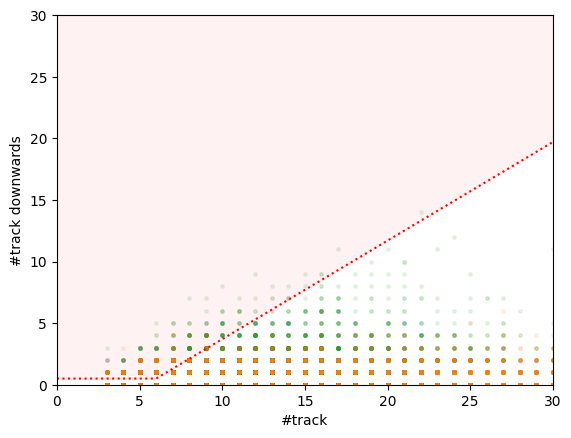

In [115]:
f_ndown_cut = lambda x: ((x-6)*.8 + 0.5) * (x >=6) + 0.5 * (x<6)
c_ndown = lambda data: (res["event_ndownward_track"][:,0] + res["event_ndownward_track"][:,1])< f_ndown_cut(res["event_ntracks"])
# c_ndown = lambda data: (res["event_ndownward_track"])< f_ndown_cut(res["event_ntracks"])

for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    res.add_cut(c_ndown, "N track downward")

    # mask = res.get_cut("N_hits vs N_veto") & res.get_cut("N_hits vs N_veto 2") # & res.get_cut("N_tracks") #| res.get_cut("True")
    mask = res.get_cut("More than 2 tracks") #| res.get_cut("True")

    x = (res["event_ntracks"])[mask]
    y = (res["event_ndownward_track"][:,0] + res["event_ndownward_track"][:,1])[mask]
    # y = (res["event_ndownward_track"])[mask]
    plt.scatter(x, y, alpha=0.1, s=6, color=colors[i])


xlim=30
ylim=30
x_plot = np.linspace(0,xlim,100)
plt.plot(x_plot, f_ndown_cut(x_plot), color="r", linestyle=":")
plt.fill_between(x_plot, f_ndown_cut(x_plot), ylim, color="r", alpha=0.05)
plt.xlabel("#track")
plt.ylabel("#track downwards")
plt.xlim(0,xlim)
plt.ylim(0,ylim)


7844
7906
31631


/tmp/ipykernel_127907/953892032.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


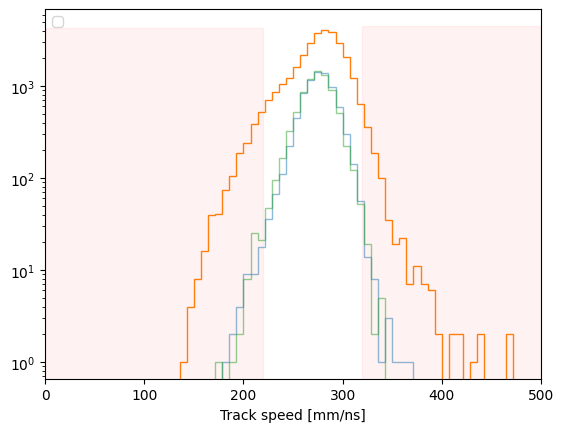

In [164]:
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    mask = res.get_cut("More than 2 tracks") #& res.get_cut("N track downward")
    print(sum(mask))
    plt.hist(res["vertex_slowest_track"][mask], bins=70,range=(0,500), alpha=0.5+ np.heaviside(i-1, 0) * 0.5, color=colors[i], histtype="step");

    res.add_cut(lambda res: (res["vertex_slowest_track"]> 220) & (res["vertex_slowest_track"]<320), "Track velocity")
    
plt.xlabel("Track speed [mm/ns]")
plt.fill_betweenx(np.linspace(*plt.gca().get_ylim()), 0, 220, color="r", alpha=0.05)
plt.fill_betweenx(np.linspace(*plt.gca().get_ylim()), 320, 500, color="r", alpha=0.05)

plt.xlim(0,500)
plt.yscale("log")
# plt.axvline(275)
plt.legend()
plt.show()

(0.0, 400.0)

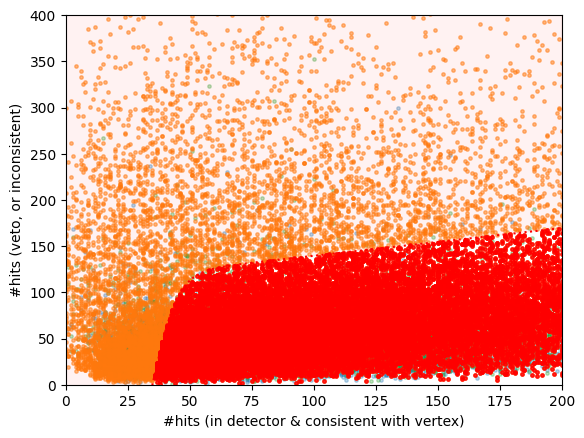

In [117]:
N_VETO_THRESHOLD=150
# f_nhits_cut = lambda x: (x-30)*7
# def f_nhits_cut_plot(x):
#     y  = f_nhits_cut(x)
#     y_threshold = N_VETO_THRESHOLD
#     return y * (y <= y_threshold) + y_threshold*(y > y_threshold)
def f_nhits_cut(x):
    x0 = 35
    squeeze = 10
    yscale = 120
    slope = 0.3
    y =  np.tanh((x-x0)/squeeze ) * yscale * (1+ (x-x0)/yscale * slope)
    return y
    # ((x-6)*.9 + 0.5) * (x >=6) + 0.5 * (x<6)
    # y  = (x-30)*4
    # y_threshold = 150
    # return (x-30)*4 * (y <= y_threshold) + y_threshold*(y > y_threshold)

c_nhits = lambda data: (res["event_ndigi_veto"] + res["event_ndigi_active"] - res["vertex_ndigi_veto_after_comp"] - res["vertex_ndigi_active_after_comp"]) < f_nhits_cut(res["vertex_ndigi_active_after_comp"])


for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    mask = res.get_cut("More than 2 tracks") # & res.get_cut("N track downward")#| res.get_cut("True")
    x = (res["vertex_ndigi_active_after_comp"])[mask]
    y = (res["event_ndigi_veto"] + res["event_ndigi_active"] - res["vertex_ndigi_veto_after_comp"] - res["vertex_ndigi_active_after_comp"])[mask]
    plt.scatter(x, y,  alpha=0.3+ np.heaviside(i-1, 0) * 0.2, s=6, color=colors[i])

    res.add_cut(c_nhits, "N_hits vs N_veto")

# confirm cut
res = res_bkg
mask = res.get_cut("More than 2 tracks") & res.get_cut("N_hits vs N_veto")
x = (res["vertex_ndigi_active_after_comp"])[mask]
y = (res["event_ndigi_veto"] + res["event_ndigi_active"] - res["vertex_ndigi_veto_after_comp"] - res["vertex_ndigi_active_after_comp"])[mask]
plt.scatter(x, y,  alpha=0.8, s=6, color="r")


xlim = 200
ylim = 400
x_plot = np.linspace(0,xlim,100)
plt.plot(x_plot, f_nhits_cut(x_plot), color="r", linestyle=":")
plt.fill_between(x_plot, f_nhits_cut(x_plot), ylim, color="r", alpha=0.05)
plt.xlabel("#hits (in detector & consistent with vertex)")
plt.ylabel("#hits (veto, or inconsistent)")
plt.xlim(0,xlim)
plt.ylim(0,ylim)

# plt.xlim(0,56)
# plt.ylim(0,56) =

7844
7906
31631


(0.0, 250.0)

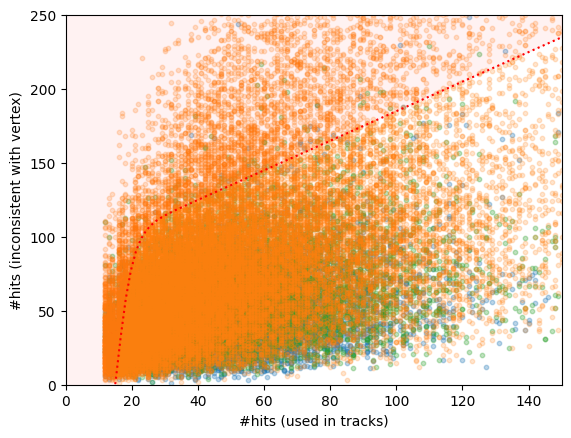

In [118]:
def f_nhits_cut2(x):
    line = (x-6)*4.6
    ycut = 22
    return line * (line>ycut) +  ycut * (line<=ycut)

def f_nhits_cut2(x):
    x0 = 15
    squeeze = 5
    yscale = 100
    slope = 1
    y =  np.tanh((x-x0)/squeeze ) * yscale * (1+ (x-x0)/yscale * slope)
    # return y * (y>20) + 20 * (y<=20)
    return y
    
c_nhits2 = lambda data: (res["event_nhits"] - res["vertex_ndigi_active_after_comp"]) < f_nhits_cut2(res["event_track_nhits"])

for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    mask = res.get_cut("More than 2 tracks") #&res.get_cut("N_hits vs N_veto") #| res.get_cut("True")
    print(sum(mask))
    # mask = res.get_cut("True")
    # mask = res.get_cut("N_tracks") 


    x = (res["event_track_nhits"])[mask]
    y = (res["event_nhits"]- res["vertex_ndigi_active_after_comp"])[mask]
    # y = (res["event_nhits"] - res["event_track_nhits"] + res["vertex_ndigi"]- res["vertex_ndigi_active_after_comp"])[mask]
    plt.scatter(x, y, alpha=0.3+ np.heaviside(i-1, 0) * -0.1, s=10, color=colors[i])

    # Add new cut
    res.add_cut(c_nhits2, "N_hits vs N_veto 2")


xlim=150
ylim=250
x_plot = np.linspace(0,xlim,100)
plt.plot(x_plot, f_nhits_cut2(x_plot), color="r", linestyle=":")
plt.fill_between(x_plot, f_nhits_cut2(x_plot), ylim, color="r", alpha=0.05)

plt.xlabel("#hits (used in tracks)")
plt.ylabel("#hits (inconsistent with vertex)")
plt.xlim(0,xlim)
plt.ylim(0,ylim)

7844
7906
31631


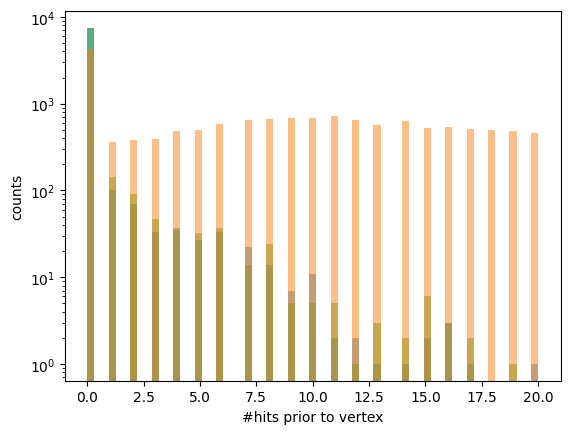

In [119]:
c_track_before = lambda data: res["vertex_ndigi_before_limited"] <= 0

for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    res.add_cut(c_track_before, "N digi before")
    mask =   res.get_cut("More than 2 tracks") # res.get_cut("N_hits vs N_veto") &res.get_cut("N_hits vs N_veto 2") #| res.get_cut("True") res.get_cut("N track downward") & res.get_cut("Track velocity") &
    # mask =  res.get_cut("True") 
    print(sum(mask))    
    plt.hist(res["vertex_ndigi_before_limited"][mask], range=(0,20), bins=21*3, alpha=0.5, color=colors[i])
plt.xlabel("#hits prior to vertex")
plt.ylabel("counts")
plt.yscale("log")

(-1.0, 1.0)

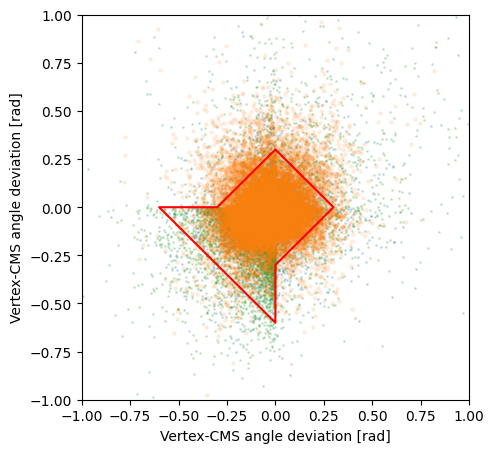

In [120]:
# c_angle_hv = lambda data: ((abs(res["vertex_cms_angle_h"])<0.5) & (abs(res["vertex_cms_angle_v"]) < 0.5))
# c_angle_hv = lambda data: (((res["vertex_cms_angle_h"])<0.2) & ((res["vertex_cms_angle_v"]) < 0.2))

cut_angel_v1 = 0.3
cut_angel_v2 = 0.6
c_angle_hv = lambda data: (abs(res["vertex_cms_angle_h"]) + abs(res["vertex_cms_angle_v"]) < cut_angel_v1) | \
        (((-res["vertex_cms_angle_h"] - res["vertex_cms_angle_v"]) < cut_angel_v2) & (res["vertex_cms_angle_h"]<0.02) & (res["vertex_cms_angle_v"]<0.02))

# c_angle_hv = lambda data: (((-res["vertex_cms_angle_h"] - res["vertex_cms_angle_v"]) < 0.5) & (res["vertex_cms_angle_h"]<0.02) & (res["vertex_cms_angle_v"]<0.02))

plt.figure(figsize=(5,5))
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    res.add_cut(c_angle_hv, "Angle to CMS")
    mask = res.get_cut("More than 2 tracks") & res.get_cut("N track downward") # & res.get_cut("Track velocity") & res.get_cut("N digi before") & res.get_cut("N_hits vs N_veto") & res.get_cut("N_hits vs N_veto 2") # &res.get_cut("N_tracks")  | res.get_cut("True")
    # mask = res.get_cut("True")
    
    x = (res["vertex_cms_angle_h"])[mask]
    y = res["vertex_cms_angle_v"][mask]
    plt.scatter(x, y, alpha=0.2 + np.heaviside(i-1, 0) * (-0.1), s=1 + np.heaviside(i-1, 0) * (4), color=colors[i])




# Plot the cut region
col = mpl.collections.PolyCollection([[[-cut_angel_v1,0], [0, cut_angel_v1], [cut_angel_v1,0], [0, -cut_angel_v1], [0,-cut_angel_v2], [-cut_angel_v2,0]]], alpha=1, edgecolors="r")
col.set_linewidth(1.5)
col.set_facecolor('none')  # Transparent face
plt.gca().add_collection(col)


plt.xlabel("Vertex-CMS angle deviation [rad]")
plt.ylabel("Vertex-CMS angle deviation [rad]")
# plt.yscale("log")
plt.xlim(-1,1)
plt.ylim(-1,1)

7003
5787
5582


Text(0, 0.5, 'Vertex-CMS deviation [rad]')

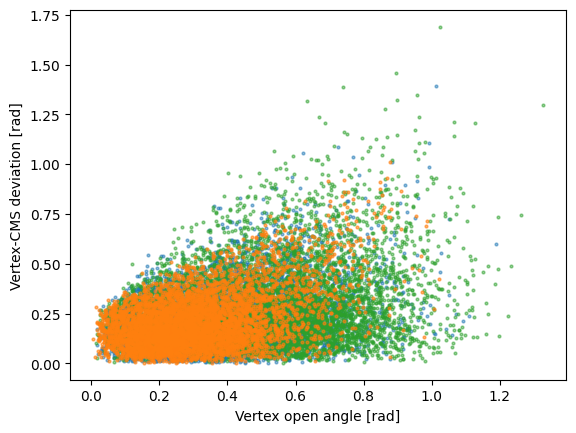

In [121]:

f_cms_angle = lambda x: x+0.5
c_nhits2 = lambda data: (res["vertex_cms_angle"]) < f_cms_angle(res["vertex_open_angle"])

for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    # res.add_cut(c_nhits2, "Angle to CMS 2")

    mask =  res.get_cut("N track downward") & \
            res.get_cut("N digi before") & \
            res.get_cut("Track velocity") & \
            res.get_cut("Angle to CMS") #| res.get_cut("True")

    # mask = res.get_cut("More than 2 tracks")
    # mask = res.get_cut("True")
    print(sum(mask))

    # mask = res.get_cut("N track downward") & res.get_cut("N_hits vs N_veto")
    # mask = res.get_cut("N track downward") & res.get_cut("N_hits vs N_veto") & res.get_cut("N track upward") & res.get_cut("N digi before") #| res.get_cut("True")

    x = res["vertex_open_angle"][mask]
    y = res["vertex_cms_angle"][mask] # vertex_cms_angle_h vertex_cms_angle
    # plt.scatter(x, y, alpha=0.3 + np.heaviside(i-1, 0) * (-0.2), s=1, color=colors[i])
    plt.scatter(x, y, alpha=0.5 + np.heaviside(i-1, 0) * (0.1), s=4, color=colors[i])

plt.xlabel("Vertex open angle [rad]")
plt.ylabel("Vertex-CMS deviation [rad]")
# plt.yscale("log")

In [122]:
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    
    name = "More than 3 tracks"
    func = lambda res: res["vertex_ntracks"]>3
    res.add_cut(func, name)   

In [123]:
def list_cut():
    for i in range(len(self.cuts_name)):
        name = self.cuts_name[i]
        mask = self.cuts_dict[name].get_mask()
        print(f"Cut {i:<2}: {name: <20}, passage fraction {sum(mask)/len(mask):.7f}, (& > 2 tracks): {sum(mask&self.mask_2)/len(self.mask_2):.7f}")
    pass

def print_active():
    mask = self.mask_true
    print(f"Total events: {len(mask)}")
    for i in self.cuts_active:
        name = self.cuts_name[i]
        mask = mask & self.cuts_dict[name].get_mask()
        print(f"Cut {i:<2}: {name: <20}, npassed {sum(mask):>6}, passage fraction {sum(mask)/len(mask):.7f}")
    pass        

self=res

cuts_indirect = [6,7,2,3,]
cuts_direct = [8,4,5]

self.cuts_active = cuts_indirect + cuts_direct
print_active()

print()
self.cuts_active =  cuts_direct + cuts_indirect
print_active()

Total events: 81833
Cut 6 : N_hits vs N_veto 2  , npassed  46904, passage fraction 0.5731673
Cut 7 : N digi before       , npassed   5139, passage fraction 0.0627986
Cut 2 : Fiducial volume     , npassed   2355, passage fraction 0.0287781
Cut 3 : N track downward    , npassed   2206, passage fraction 0.0269573
Cut 8 : Angle to CMS        , npassed   1793, passage fraction 0.0219105
Cut 4 : Track velocity      , npassed   1668, passage fraction 0.0203830
Cut 5 : N_hits vs N_veto    , npassed   1443, passage fraction 0.0176335

Total events: 81833
Cut 8 : Angle to CMS        , npassed  62529, passage fraction 0.7641049
Cut 4 : Track velocity      , npassed  54579, passage fraction 0.6669559
Cut 5 : N_hits vs N_veto    , npassed  36483, passage fraction 0.4458226
Cut 6 : N_hits vs N_veto 2  , npassed  31666, passage fraction 0.3869588
Cut 7 : N digi before       , npassed   3473, passage fraction 0.0424401
Cut 2 : Fiducial volume     , npassed   1500, passage fraction 0.0183300
Cut 3 : N 

6515
5387
3347


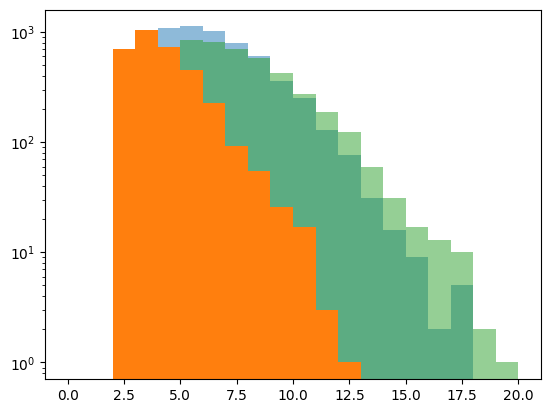

In [124]:
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    mask =  res.get_cut("N_hits vs N_veto") & \
            res.get_cut("N_hits vs N_veto 2") & \
            res.get_cut("N track downward") & \
            res.get_cut("N digi before") & \
            res.get_cut("Track velocity") & \
            res.get_cut("Angle to CMS") #| res.get_cut("True")

    mask =  res.get_cut("N_hits vs N_veto") & \
            res.get_cut("N_hits vs N_veto 2") & \
            res.get_cut("N track downward") & \
            res.get_cut("N digi before") & \
            res.get_cut("Track velocity") & \
            res.get_cut("Angle to CMS") #| res.get_cut("True")    
    
    print(sum(mask))
    # plt.hist((res["vertex_ntracks"] - res["vertex_ndownward_track"])[mask], bins=20,range=(0,20), alpha=0.5);
    plt.hist(res["vertex_ntracks"][mask], bins=20,range=(0,20), alpha=0.5+ np.heaviside(i-1, 0) * 0.5, color=colors[i]);
plt.yscale("log")
plt.show()

In [140]:
# for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
#     mask = res.get_cut("More than 2 tracks")
#     mask = res.get_cut("N track downward") & res.get_cut("N digi before") & res.get_cut("Angle to CMS")
  
#     print(sum(mask))
#     # plt.hist((res["vertex_ntracks"] - res["vertex_ndownward_track"])[mask], bins=20,range=(0,20), alpha=0.5);
#     plt.hist(res["vertex_ndigi_veto_after_comp"][mask], bins=40,range=(0,100), alpha=0.5+ np.heaviside(i-1, 0) * 0.5, color=colors[i], histtype="step");
# plt.yscale("log")
# plt.show()

(-1.0, 100.0)

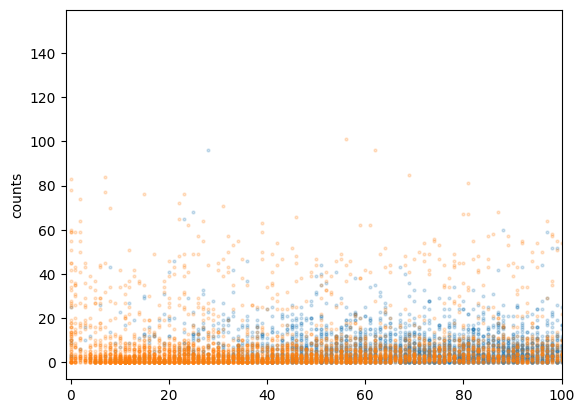

In [126]:
for res in [res_sig2, res_bkg]:
    mask =  res.get_cut("N_hits vs N_veto") & \
            res.get_cut("N_hits vs N_veto 2") & \
            res.get_cut("N track downward") & \
            res.get_cut("N digi before") & \
            res.get_cut("Angle to CMS") #| res.get_cut("True")

    mask = res.get_cut("N track downward") & res.get_cut("N digi before") & res.get_cut("Angle to CMS")
    # plt.hist(res["vertex_ndigi_veto_after_comp"][mask], bins=51, alpha=0.5, range=(-1,20))
    plt.scatter(res["vertex_ndigi_active_after_comp"][mask],(res["vertex_ndigi_veto_after"] - res["vertex_ndigi_veto_after_comp"])[mask], s=4, alpha=0.2)
    # plt.scatter(res["vertex_ndigi_active_after_comp"][mask],res["vertex_ndigi_veto_after"][mask], s=10, alpha=0.5)

plt.ylabel("counts")
# plt.yscale("log")
plt.xlim(-1,100)
# plt.ylim(-1,100)

7234
7198
23585


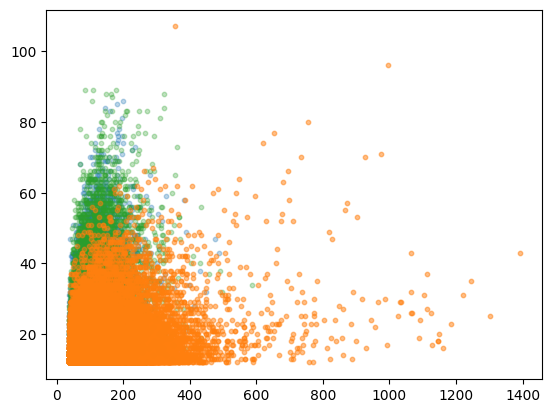

In [127]:
for i, res in enumerate([res_sig1, res_sig2, res_bkg]):
    mask = res.get_cut("More than 2 tracks") &res.get_cut("N_hits vs N_veto") #| res.get_cut("True")
    print(sum(mask))
    # mask = res.get_cut("True")
    # mask = res.get_cut("N_tracks") 


    x = (res["vertex_ndigi_active_after_comp"])[mask]
    y = (res["vertex_ndigi"])[mask]
    # y = (res["event_nhits"] - res["event_track_nhits"] + res["vertex_ndigi"]- res["vertex_ndigi_active_after_comp"])[mask]
    plt.scatter(x, y, alpha=0.3+ np.heaviside(i-1, 0) * 0.2, s=10, color=colors[i])

In [130]:
res = res_bkg
mask = res.get_cut("More than 2 tracks") &res.get_cut("N_hits vs N_veto")&res.get_cut("N_hits vs N_veto 2") #| res.get_cut("True")
mask = res.get_cut("N_hits vs N_veto") & \
            res.get_cut("N_hits vs N_veto 2") & \
            res.get_cut("N track downward") & \
            res.get_cut("N digi before") & \
            res.get_cut("Track velocity") & \
            res.get_cut("Angle to CMS") #| res.get_cut("True")

        # res.get_cut("Angle to CMS") #| res.get_cut("True")
print(sum(mask))
plotinds = res["ROOT_entry"][mask]

3347


24 648


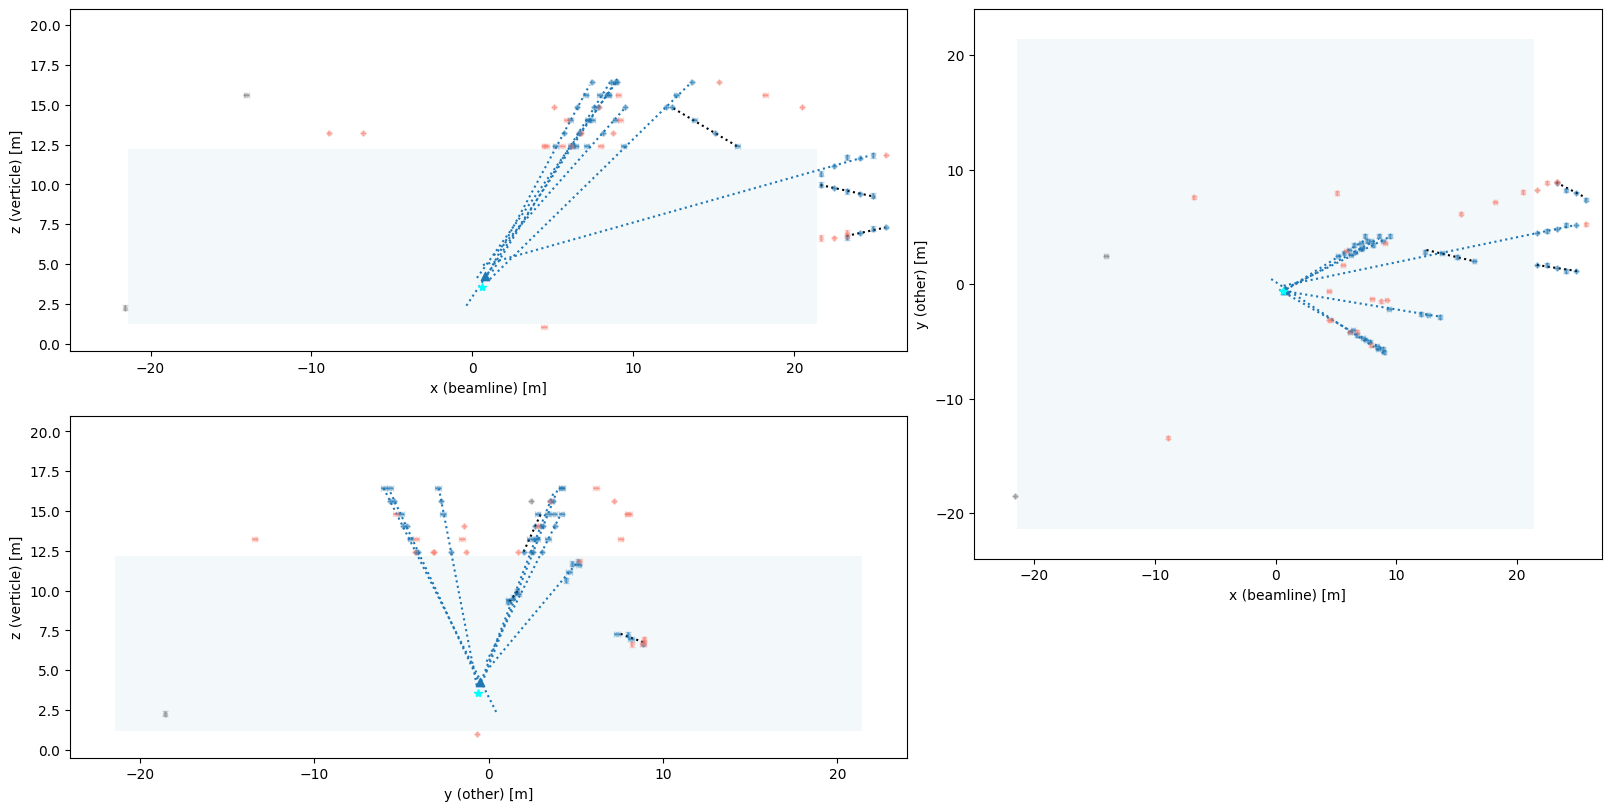

In [152]:
i+=1
# i=0
j=plotinds[i]
print(i, j)

data = fbkg.get_entry(j)
event = datatypes.Event(data, metadata_digi)  
event.plot()

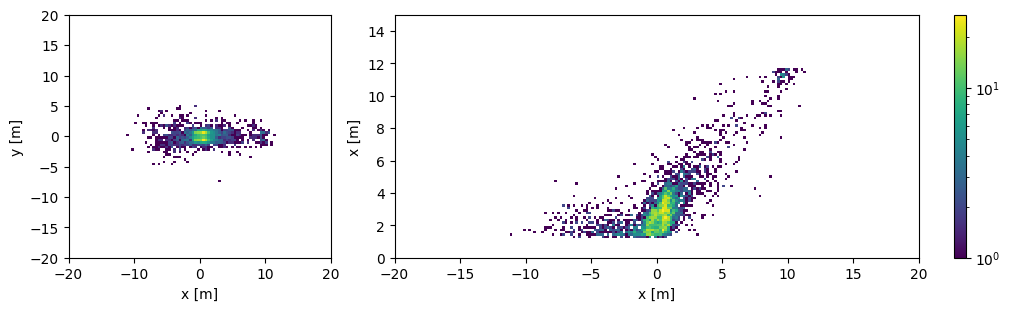

In [163]:
for i, res in enumerate([res_bkg]):
    # mask = res.get_cut("More than 2 tracks") #& res.get_cut("N track downward")#| res.get_cut("True")
    mask_scatter = res.get_cut("More than 2 tracks") &res.get_cut("N_hits vs N_veto")&res.get_cut("N_hits vs N_veto 2") #| res.get_cut("True")
    mask = res.get_cut("N_hits vs N_veto") & \
                res.get_cut("N_hits vs N_veto 2") & \
                res.get_cut("N track downward") & \
                res.get_cut("N digi before") & \
                res.get_cut("Track velocity") & \
                res.get_cut("Angle to CMS") #| res.get_cut("True")
    
    # print(sum(mask))
    fig = plt.figure(figsize=(10,3), layout="constrained")
    spec = fig.add_gridspec(1,3)
    
    ax1 = fig.add_subplot(spec[:, :1])
    ax2 = fig.add_subplot(spec[:, 1:])

    x = (res["vertex_xyzt"][:,0])[mask]*0.001
    y = (res["vertex_xyzt"][:,1])[mask]*0.001
    xs = (res["vertex_xyzt"][:,0])[mask_scatter]*0.001
    ys = (res["vertex_xyzt"][:,1])[mask_scatter]  *0.001  
    ax1.hist2d(x, y, bins=(100,100), norm=mpl.colors.LogNorm(), range=((-20,20),(-20,20)))
    # ax1.scatter(xs, ys, alpha=0.83 - np.heaviside(i-1,0)*0.08, s=20 - np.heaviside(i-1,0)*1, color="r")
    ax1.set_xlabel("x [m]")
    ax1.set_ylabel("y [m]")

    x = (res["vertex_xyzt"][:,0])[mask]*0.001
    y = (res["vertex_xyzt"][:,2])[mask]*0.001
    xs = (res["vertex_xyzt"][:,0])[mask_scatter]*0.001
    ys = (res["vertex_xyzt"][:,2])[mask_scatter]*0.001
    plt.sca(ax2)
    plt.hist2d(x, y, bins=(200,100), norm=mpl.colors.LogNorm(), range=((-20,20),(0,15)))
    # ax2.scatter(xs, ys, alpha=0.83 - np.heaviside(i-1,0)*0.08, s=20 - np.heaviside(i-1,0)*1, color="r")
    plt.xlabel("x [m]")
    plt.ylabel("x [m]")
    plt.colorbar()
    
    plt.show()